# IDENTITAS DIRI
Nama : Muhammad Rayhan Zamzami

NIM : 244107020027

Kelas : TI-3G

Absen : 19

In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/ml-semester5/dataset/diabetes_012_health_indicators_BRFSS2015.csv')

df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
# Melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [7]:
# Memisahkan target dan fitur
target = df['Diabetes_012']

X = df.drop(columns=['Diabetes_012'])

X.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [21]:
# Standardisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[ 1.15368814,  1.16525449,  0.19692156,  1.75793567,  1.12092719,
        -0.20563655, -0.3224576 , -1.76281393, -1.31687168,  0.48208665,
        -0.24401415,  0.22686264, -0.30317313,  2.32912057,  1.99859213,
         1.23399871,  2.22361507, -0.88702088,  0.31690008, -1.06559465,
        -1.4744874 ],
       [-0.86678537, -0.85818163, -5.07816412, -0.51180614,  1.12092719,
        -0.20563655, -0.3224576 ,  0.56727485, -1.31687168, -2.07431589,
        -0.24401415, -4.40795367,  3.29844532,  0.45729435, -0.42962961,
        -0.48659241, -0.44971813, -0.88702088, -0.33793279,  0.96327159,
        -2.44013754],
       [ 1.15368814,  1.16525449,  0.19692156, -0.05785778, -0.8921186 ,
        -0.20563655, -0.3224576 , -1.76281393,  0.75937543, -2.07431589,
        -0.24401415,  0.22686264,  3.29844532,  2.32912057,  3.61740662,
         2.95458982,  2.22361507, -0.88702088,  0.31690008, -1.06559465,
         0.93963796],
       [ 1.15368814, -0.85818163,  0.19692156, -0.2091739 

In [9]:
# Mengambil sampel data
sample_size = 10000

np.random.seed(42)

sample_idx = np.random.choice(
    X_scaled.shape[0],
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_idx]

target_sample = target.iloc[sample_idx].reset_index(drop=True)

X_sample.shape

(10000, 21)

In [10]:
# DBSCAN Manhattan
dbscan = DBSCAN(
    eps=5,
    min_samples=10,
    metric='manhattan',
    n_jobs=-1
)

labels = dbscan.fit_predict(X_sample)

labels

array([ 0,  0,  0, ..., -1,  0,  0])

In [11]:
# Menambahkan hasil cluster
df_cluster = pd.DataFrame(
    X_sample,
    columns=X.columns
)

df_cluster['Cluster'] = labels
df_cluster['Diabetes_012'] = target_sample

df_cluster.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Cluster,Diabetes_012
0,-0.866785,-0.858182,0.196922,-1.117071,-0.892119,-0.205637,-0.322458,-1.762814,0.759375,0.482087,...,0.457294,-0.024926,0.316350,-0.449718,-0.887021,-0.337933,-1.065595,-1.957312,0,0.0
1,1.153688,1.165254,0.196922,-0.057858,-0.892119,-0.205637,-0.322458,0.567275,0.759375,0.482087,...,0.457294,-0.429630,-0.486592,-0.449718,-0.887021,1.626566,0.963272,-0.026012,0,0.0
2,-0.866785,-0.858182,0.196922,-0.663122,-0.892119,-0.205637,-0.322458,0.567275,0.759375,0.482087,...,-1.414532,-0.429630,-0.486592,-0.449718,1.127369,-2.302431,-1.065595,0.456813,0,0.0
3,-0.866785,-0.858182,0.196922,-0.209174,1.120927,-0.205637,-0.322458,0.567275,-1.316872,0.482087,...,-0.478619,-0.024926,-0.486592,-0.449718,1.127369,-1.975015,-1.065595,0.456813,0,0.0
4,-0.866785,1.165254,0.196922,0.396091,1.120927,-0.205637,-0.322458,-1.762814,0.759375,0.482087,...,1.393207,3.212703,2.610472,2.223615,-0.887021,-0.010516,-2.080028,-1.957312,-1,0.0


In [19]:
# Jumlah data setiap cluster
cluster_counts = df_cluster['Cluster'].value_counts().sort_index()

print(cluster_counts)

# Jumlah cluster tanpa noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Jumlah noise
n_noise = list(labels).count(-1)

print("Jumlah Cluster :", n_clusters)
print("Jumlah Noise   :", n_noise)

# Data tanpa noise
mask = labels != -1

X_eval = X_sample[mask]
labels_eval = labels[mask]

# Evaluasi Silhouette Score
if len(set(labels_eval)) > 1:
    silhouette = silhouette_score(
        X_eval,
        labels_eval,
        metric='manhattan'
    )
    print("Silhouette Score (Manhattan):", silhouette)
else:
    print("Silhouette Score tidak dapat dihitung karena cluster kurang dari 2.")

# Evaluasi Davies-Bouldin Index
if len(set(labels_eval)) > 1:
    dbi = davies_bouldin_score(
        X_eval,
        labels_eval
    )
    print("Davies-Bouldin Index:", dbi)
else:
    print("DBI tidak dapat dihitung.")

# Evaluasi Calinski-Harabasz Index
if len(set(labels_eval)) > 1:
    ch = calinski_harabasz_score(
        X_eval,
        labels_eval
    )
    print("Calinski-Harabasz Index:", ch)
else:
    print("CH Index tidak dapat dihitung.")

Cluster
-1    2496
 0    7252
 1     184
 2      47
 3       6
 4       8
 5       7
Name: count, dtype: int64
Jumlah Cluster : 6
Jumlah Noise   : 2496
Silhouette Score (Manhattan): 0.09504969105728245
Davies-Bouldin Index: 1.5077579898865998
Calinski-Harabasz Index: 109.78382146588564


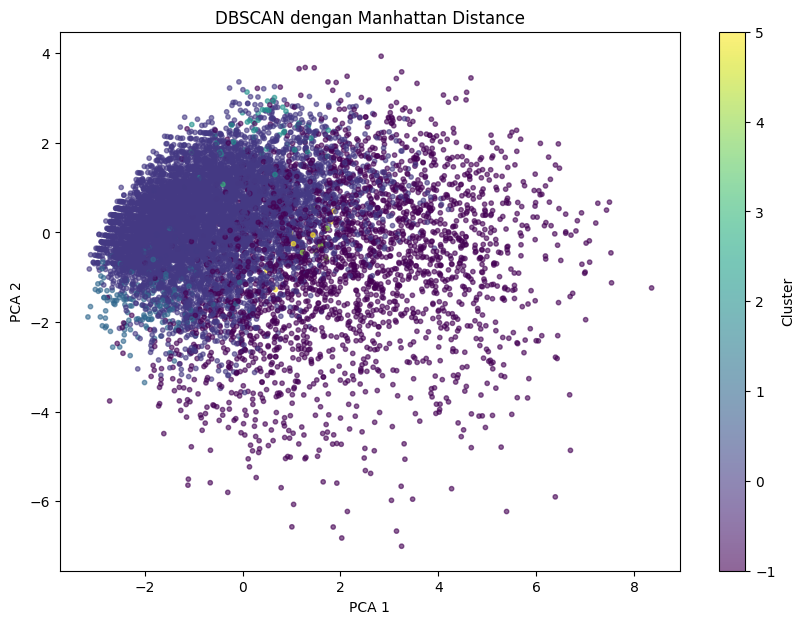

In [17]:
# Reduksi dimensi menjadi 2D
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    s=10,
    alpha=0.6
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('DBSCAN dengan Manhattan Distance')
plt.colorbar(scatter, label='Cluster')

plt.show()

In [25]:
# Simpan hasil clustering
df_cluster.to_csv(
    '/content/drive/MyDrive/ml-semester5/dataset/diabetes_dbscan_manhattan_results.csv',
    index=False
)

print("Hasil berhasil disimpan.")

Hasil berhasil disimpan.
